In [3]:
import sys
sys.path.append("../")

from methods.Steepest_descent import (gradient_descent)
from methods.Error import (save_iterations, history, calculate_precision, plot_methods_error, ten_iterations)
from methods.Newton_method import (newton_method)
from methods.Conjugate_method import (conjugate_gradient)
import numpy as np
import os
import matplotlib.pyplot as plt

-----------------------------
Method:  Gradient_descent
Minimum point:  [2. 2.]
Function value at minimum:  6.0
Number of iterations:  34
-----------------------------


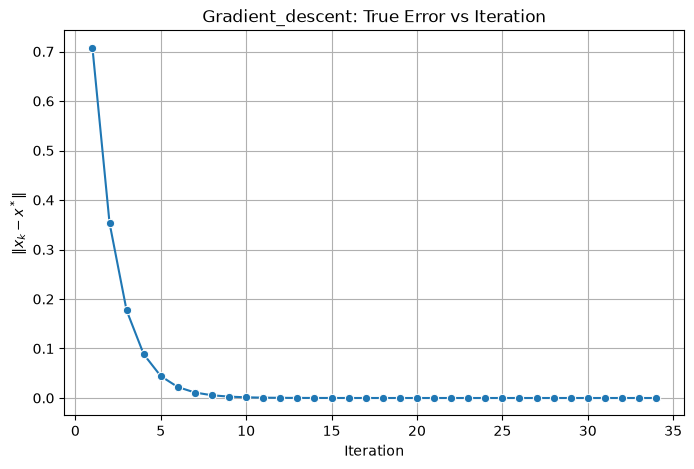

-----------------------------
Method:  Newton Method
Minimum point:  [2. 2.]
Function value at minimum:  6.0
Number of iterations:  2
-----------------------------


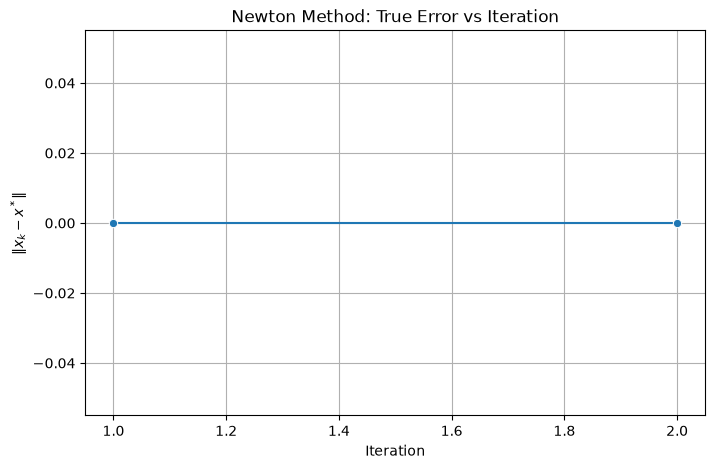

-----------------------------
Method:  Conjugate Gradient Method
Minimum point:  [2. 2.]
Function value at minimum:  6.0
Number of iterations:  1
-----------------------------


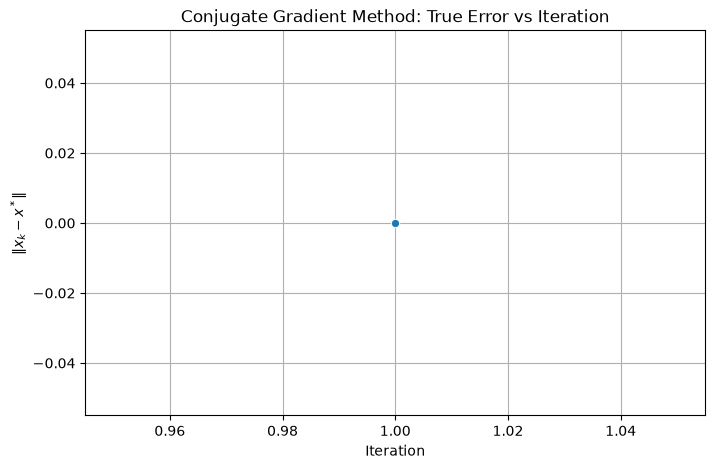

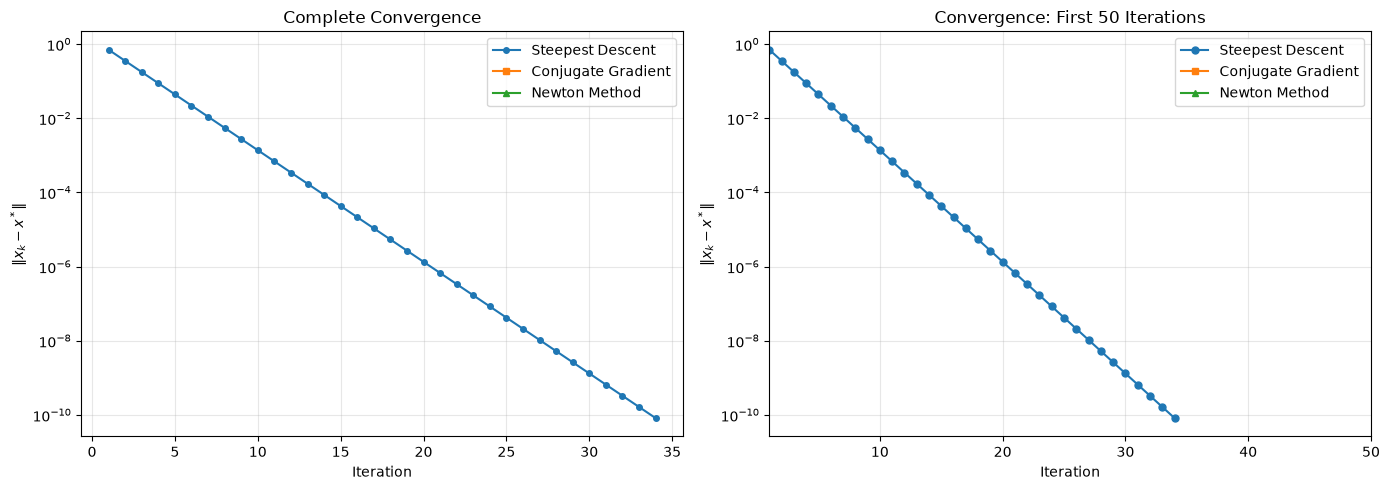

Plot saved: results\plots\methods_comparison_error.png
               Method  Iterations   Final Error  Correct Decimals
0    Steepest Descent          34  8.231806e-11               9.0
1  Conjugate Gradient           1  0.000000e+00               inf
2       Newton Method           2  0.000000e+00               inf

Database saved: results\methods_precision.csv
                Method  iteration        x1        x2      f(x)  gradient_x1  \
0     Steepest Descent          1  1.500000  2.500000  6.250000    -1.000000   
1     Steepest Descent          2  1.750000  2.250000  6.062500    -0.500000   
2     Steepest Descent          3  1.875000  2.125000  6.015625    -0.250000   
3     Steepest Descent          4  1.937500  2.062500  6.003906    -0.125000   
4     Steepest Descent          5  1.968750  2.031250  6.000977    -0.062500   
5     Steepest Descent          6  1.984375  2.015625  6.000244    -0.031250   
6     Steepest Descent          7  1.992188  2.007812  6.000061    -0.0156

In [4]:
import numpy as np


# ============================================================
# Objective function
# f(x1, x2) = (x1-d)^2 + x1*x2 + (x2-d)^2
# ============================================================

def f(x, y):

    d = 3

    return (x - d)**2 + x*y + (y - d)**2


# ============================================================
# Partial derivatives
# ============================================================

def df_dx(x, y):

    d = 3

    return 2*(x - d) + y


def df_dy(x, y):

    d = 3

    return x + 2*(y - d)


# ============================================================
# Gradient
# ============================================================

def gradient(x, y):

    return np.array([
        df_dx(x, y),
        df_dy(x, y)
    ])


# ============================================================
# Hessian
# ============================================================

def hessian(x, y):

    return np.array([
        [2, 1],
        [1, 2]
    ])


# ============================================================
# Printing results
# ============================================================

def printing(method, minimum, f_min, iterations):

    print("-----------------------------")
    print("Method: ", method)
    print("Minimum point: ", minimum)
    print("Function value at minimum: ", f_min)
    print("Number of iterations: ", iterations)
    print("-----------------------------")


# ============================================================
# Initial point and parameters
# ============================================================

d = 3

x0 = np.array([1.0, 3.0])

tol = 1e-10

max_iter = 1000


# ============================================================
# Exact solution
# ============================================================

x_exact = np.array([
    2.0,
    2.0
])


# ============================================================
# Step size for Steepest Descent
# ============================================================

alpha = 0.5


# ============================================================
# Main
# ============================================================

if __name__ == "__main__":

    # --------------------------------------------------------
    # Steepest Descent
    # --------------------------------------------------------

    minimum, f_min, iterations, history_data = gradient_descent(
        x0,
        f,
        gradient,
        tol,
        max_iter,
        alpha,
        history
    )

    printing(
        'Gradient_descent',
        minimum,
        f_min,
        iterations
    )

    df_gradient = save_iterations(
        history_data,
        "Gradient_descent",
        x_exact
    )


    # --------------------------------------------------------
    # Newton Method
    # --------------------------------------------------------

    minimum, f_min, iterations, history_data = newton_method(
        x0,
        f,
        gradient,
        hessian,
        tol,
        max_iter,
        alpha,
        history
    )

    printing(
        'Newton Method',
        minimum,
        f_min,
        iterations
    )

    df_newton = save_iterations(
        history_data,
        "Newton Method",
        x_exact
    )


    # --------------------------------------------------------
    # Conjugate Gradient
    # --------------------------------------------------------

    minimum, f_min, iterations, history_data = conjugate_gradient(
        x0,
        f,
        gradient,
        tol,
        max_iter,
        history
    )

    printing(
        'Conjugate Gradient Method',
        minimum,
        f_min,
        iterations
    )

    df_conjugate = save_iterations(
        history_data,
        "Conjugate Gradient Method",
        x_exact
    )


    # --------------------------------------------------------
    # Results
    # --------------------------------------------------------

    results_path = "results"

    plot_methods_error(results_path)

    calculate_precision(results_path)

    ten_iterations(results_path)